# DEMO sprint 8 - Deel 1 (Afronding DAM-Live berekening)

### Benodigde generieke Python packages

In [1]:
from pathlib import Path
import datetime
import matplotlib.pyplot as plt

## Ophalen van belastingen vanuit FEWS (voorbeeld HHNK)

We gebruiken HHNK FEWS als voorbeeld op 'actuele' (grond)waterstanden op te halen.
Benodigde bestanden:
- Een CSV bestand met FEWS locaties (4 peilbuizen en 1 oppervlaktewater meetpunt)

<details>
<summary>Configuratie</summary>

```yaml
GlobalVariables:
    rootdir: "data_demo/preprocess"
    moments: [0, 24]
    calc_time: "2024-11-06 08:00:00"
    aquo_alias:
        H.meting: "WATHTE"
        WATHTE [m][NAP][OW]: "WATHTE"

    LoadsFews:
        host: "https://fews.hhnk.nl"
        port: 443
        region: "fewspiservice"
        version: "1.25"
        parameters: ["H.meting", "WATHTE [m][NAP][OW]"]

DataAdapter:
    default_options:
        csv:
            sep: ","
    locaties:
        type: csv
        path: "locations_fews.csv"
    waterstanden:
        type: csv
        path: "hidden_waterstanden_fews.csv"
    waterstanden_xml:
        type: xml_timeseries
        path: "waterstanden_fews.xml"
        parameter_mapping:
            WATHTE: H.meting
        location_mapping:
            MPN-N-24: BP

```

</details>

### Lees configuratie in en maak dictionary base.Config aan

In [2]:
from toolbox_continu_inzicht import Config

yaml_config_file = "loads_fews_grondwater.yaml"
path = Path.joinpath(Path.cwd(), "data_demo/preprocess", yaml_config_file)
config = Config(config_path=path)
config.lees_config()

### Geef config mee aan base.Adapter

In [3]:
from toolbox_continu_inzicht import DataAdapter

data_adapter = DataAdapter(config)
print(f"Folder met data: {data_adapter.config.config_path}")
print(f"Globale variabelen: {data_adapter.config.global_variables}")

Folder met data: c:\Users\thonus\MijnSoftware\Toolbox_Continu_Inzicht\toolbox-continu-inzicht\toolbox-continu-inzicht\tests\examples\demos\dam_live\data_demo\preprocess\loads_fews_grondwater.yaml
Globale variabelen: {'rootdir': 'data_demo/preprocess', 'moments': [0, 24], 'calc_time': datetime.datetime(2024, 11, 6, 8, 0, tzinfo=datetime.timezone.utc), 'aquo_alias': {'H.meting': 'WATHTE', 'WATHTE [m][NAP][OW]': 'WATHTE'}, 'LoadsFews': {'host': 'https://fews.hhnk.nl', 'port': 443, 'region': 'fewspiservice', 'version': '1.25', 'parameters': ['H.meting', 'WATHTE [m][NAP][OW]']}}


### Laad en run module (functie) LoadFews voor ophalen 'actuele' (grond)waterstand uit FEWS

In [4]:
from toolbox_continu_inzicht.loads.loads_fews.loads_fews import LoadsFews

loads_fews = LoadsFews(data_adapter=data_adapter)
df_out = loads_fews.run(input="locaties", output="waterstanden_xml")

In [6]:
if df_out is not None:
    print("Data succesvol opgehaald uit FEWS.")
    df_waterstanden = data_adapter.input("waterstanden_xml")
else:
    print(
        "Er is een fout opgetreden bij het ophalen van data uit FEWS. Gebruik een lokaal testbestand"
    )
    data_adapter.input("waterstanden_xml")
    file = data_adapter.config.data_adapters["waterstanden_xml"]["path"]
    df_waterstanden = data_adapter.input("waterstanden_xml")

print(df_waterstanden.head())

Er is een fout opgetreden bij het ophalen van data uit FEWS. Gebruik een lokaal testbestand
                  date_time measurement_location_code parameter_code  \
0 2024-11-06 07:00:00+00:00                    PB-286       H.meting   
1 2024-11-06 08:00:00+00:00                    PB-286       H.meting   
2 2024-11-06 09:00:00+00:00                    PB-286       H.meting   
3 2024-11-06 10:00:00+00:00                    PB-286       H.meting   
4 2024-11-06 11:00:00+00:00                    PB-286       H.meting   

   parameter_id unit  value  measurement_location_id  
0       4734596    m -0.429                  5349673  
1       4734596    m -0.428                  5349673  
2       4734596    m -0.428                  5349673  
3       4734596    m -0.430                  5349673  
4       4734596    m -0.429                  5349673  


### Plot de ingelezen 'actuele'(grond)waterstanden in een grafiek

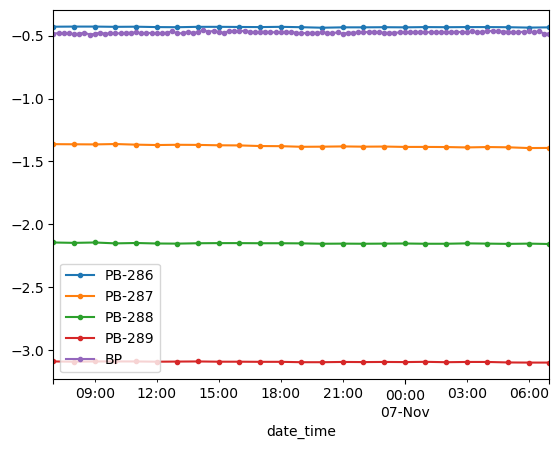

In [7]:
fig, ax = plt.subplots()
for station in df_waterstanden["measurement_location_code"].unique():
    df_station = df_waterstanden[
        df_waterstanden["measurement_location_code"] == station
    ].copy()
    df_station.rename(columns={"value": station}, inplace=True)
    df_station.plot(x="date_time", y=station, ax=ax, legend=station, marker=".")

### De 'actuele' (grond)waterstanden uitlezen op de gedefinieerde momenten

In [8]:
from toolbox_continu_inzicht.loads import LoadsToMoments

loads_to_moments = LoadsToMoments(data_adapter=data_adapter)
loads_to_moments.run(input="waterstanden_xml", output="waterstanden_xml_hourly")

### Plot de 'actuele'(grond)waterstanden voor de momenten in een grafiek

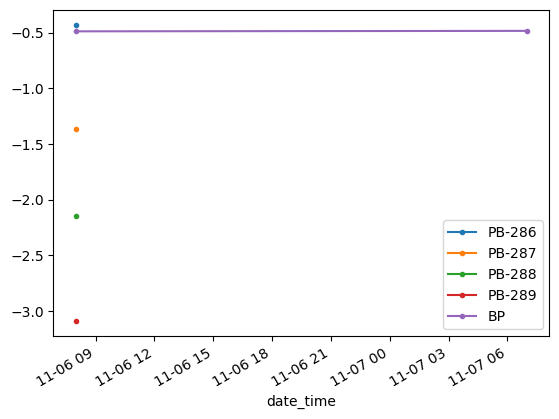

In [9]:
fig, ax = plt.subplots()
df_waterstanden_moments = loads_to_moments.df_out
for station in df_waterstanden_moments["measurement_location_code"].unique():
    df_station = df_waterstanden_moments[
        df_waterstanden_moments["measurement_location_code"] == station
    ].copy()
    df_station.rename(columns={"value": station}, inplace=True)
    df_station.plot(x="date_time", y=station, ax=ax, legend=station, marker=".")

### Voer een DAM-Live berekening uit
Let op: Om DAM-Live te kunnen gebruiken is een licentie van Deltares nodig!
Dit voorbeeld is gemaakt met DAM-Live versie 26.1.0.7015.
Kopieer de resultaten met waterstanden uit preprocess (FEWS) naar de process map!


<details>
<summary> Configuratie</summary>

```yaml
GlobalVariables:
    rootdir: "data_demo/process"
    moments: [0, 24]
    calc_time: "2024-11-06 08:00:00"
    UpdateDamLive:
        DAMLIVE_FILE: 'WV2030_Purmer.damx'
        delete_output_folder: False

DataAdapter:
    default_options:
        csv:
            sep: ","
    waterstanden_xml_uur:
        type: xml_timeseries
        path: "waterstanden_fews_hourly.xml"
    parameters_bishop_csv:
        type: csv
        index: True
        path: "parameters_bishop.csv"
    parameters_uplift_csv:
        type: csv
        index: True
        path: "parameters_uplift.csv"
    output_file:
        type: csv
        path: test.csv

``` 
</details>


### Lees configuratie in en maak dictionary base.Config aan

In [10]:
yaml_config_file = "run_damlive.yaml"
path = Path.joinpath(Path.cwd(), "data_demo/process", yaml_config_file)
config = Config(config_path=path)
config.lees_config()

### Geef config mee aan base.Adapter

In [11]:
data_adapter = DataAdapter(config)
print(f"Folder met data: {data_adapter.config.config_path}")
print(f"Globale variabelen: {data_adapter.config.global_variables}")

Folder met data: c:\Users\thonus\MijnSoftware\Toolbox_Continu_Inzicht\toolbox-continu-inzicht\toolbox-continu-inzicht\tests\examples\demos\dam_live\data_demo\process\run_damlive.yaml
Globale variabelen: {'rootdir': 'data_demo/process', 'moments': [0, 24], 'calc_time': datetime.datetime(2024, 11, 6, 8, 0, tzinfo=datetime.timezone.utc), 'UpdateDamLive': {'DAMLIVE_FILE': 'WV2030_Purmer.damx', 'delete_output_folder': False}}


### Inlezen van (grond)waterstanden en parameters voor de DAM-Live berekening
Benodigd:
- waterstanden_fews_hourly.xml met (grond)waterstanden
- parameters_bishop.csv met instelling voor Bishop berekening in DAM-Live

In [12]:
data_adapter.input("waterstanden_xml_uur")
data_adapter.input("parameters_bishop_csv")

,parameter_names,parameter_values
0,CalculationModules_StabilityInside,1
1,CalculationModules_StabilityOutside,0
2,CalculationModules_PipingBligh,0
3,CalculationModules_PipingWti,0
4,StabilityParameters_CalculationModel,Bishop
5,StabilityParameters_SearchMethod,Grid


### Benodigde databestanden voor DAM-Live berekening
- Een {prjectnaam}.damx bestand voor de DAM-Live berekening
- Een folder {prjectnaam},geometries2D}


### Geef de invoer door aan DAM-Live

In [13]:
from toolbox_continu_inzicht.dam_live import UpdateDamLive

update_dam_live = UpdateDamLive(data_adapter=data_adapter)

### Start de DAM-Live berekening (indien DAM-Live licentie beschikbaar)

In [14]:
# om meer informatie terug te krijgen van DAMLIVE, kan de logging level op INFO worden gezet.
# update_dam_live.data_adapter.set_global_variable("logging", {"level": "INFO"})
# update_dam_live.data_adapter.init_logging(re_initialize=True)
update_dam_live.run(
    input=["waterstanden_xml_uur", "parameters_bishop_csv"], output="output_file"
)

2026-06-25 09:06:31 ERROR - run: DAM Live did not produce the expected output file: C:\Users\thonus\MijnSoftware\Toolbox_Continu_Inzicht\toolbox-continu-inzicht\toolbox-continu-inzicht\tests\examples\demos\dam_live\data_demo\process\live.OutputTimeSeries.xml


### Samenvatting van de berekeningsesultaten 
Resultaatbestanden (Resultaat.csv en WV2030_Purmer.Calc (resultaat reeds uitgepakt)) zijn onderdeel van deze demo (beschikbaar zonder DAM-Live uit te voeren i.v.m. benodigde licentie DAM-Live)

In [15]:
df_output_damlive = update_dam_live.data_adapter.input("output_file")
df_output_damlive.head(10)

,Unnamed: 0,date_time,measurement_location_code,parameter_code,parameter_id,unit,value,measurement_location_id
0,0,2024-11-06 06:00:00+00:00,PU0013_87074-1_DWP001,StabilityInsideFactor,7310765,m,1.047054,1063233
1,1,2024-11-06 07:00:00+00:00,PU0013_87074-1_DWP001,StabilityInsideFactor,7310765,m,1.047253,1063233
2,2,2024-11-06 06:00:00+00:00,PU0021_87074-1_DWP002,StabilityInsideFactor,7310765,m,0.846680,1976182
3,3,2024-11-06 07:00:00+00:00,PU0021_87074-1_DWP002,StabilityInsideFactor,7310765,m,0.846996,1976182
4,4,2024-11-06 06:00:00+00:00,PU0030_87074-1_DWP003,StabilityInsideFactor,7310765,m,0.817755,1923656
5,5,2024-11-06 07:00:00+00:00,PU0030_87074-1_DWP003,StabilityInsideFactor,7310765,m,0.818512,1923656
6,6,2024-11-06 06:00:00+00:00,PU0042+8m_HHNK,StabilityInsideFactor,7310765,m,0.946750,2072011
7,7,2024-11-06 07:00:00+00:00,PU0042+8m_HHNK,StabilityInsideFactor,7310765,m,0.946422,2072011
8,8,2024-11-06 06:00:00+00:00,PU0063_87074-1_DWP004,StabilityInsideFactor,7310765,m,1.134814,191757
9,9,2024-11-06 07:00:00+00:00,PU0063_87074-1_DWP004,StabilityInsideFactor,7310765,m,1.134886,191757


### Verwerk de DAM-Live resultaten

Eerst moeten de resultaten uitgepakt worden. Mocht je problemen hebben met het uitpakken van de bestanden, kan het door de maximale pad naam lengthe van windows komen. De namen van de DamLive bestanden zijn vrij lang. Zie deze [gist](https://gist.github.com/leodutra/a25bc1f51e8779943df0a95d5a4839d1#windows-11) voor een oplossing

<details>
<summary> Configuratie</summary>

```yaml
GlobalVariables:
  rootdir: "data_demo/postprocess/WV2030_Purmer.Calc/Stability/Bishop/PU0013_87074-1_DWP001_0_2024-11-06T07"

DataAdapter:
  scenario:
    type: stages
    path: scenarios

  geometries:
    type: geometries
    path: geometries

  soillayers:
    type: soillayers
    path: soillayers

  soils:
    type: soils
    path: soils.json

  waternets:
    type: waternets
    path: waternets

  calculationsettings:
    type: calculationsettings
    path: calculationsettings

  colors:
    type: csv
    relative_file: data_demo/postprocess/colors.csv

  merge_soil:
    type: csv
    path: merged_soil.csv

  merge_waternet:
    type: csv
    path: merged_waternet.csv

  merge_calculations:
    type: csv
    path: merged_calculations.csv
``` 
</details>

### Lees configuratie in en maak dictionary base.Config aan

In [16]:
yaml_config_file = "dam_live_CI_database_config.yaml"
path = Path.joinpath(Path.cwd(), "data_demo/postprocess", yaml_config_file)
config = Config(config_path=path)
config.lees_config()

### Geef config mee aan base.Adapter

In [17]:
data_adapter = DataAdapter(config)
print(f"Folder met data: {data_adapter.config.config_path}")
print(f"Globale variabelen: {data_adapter.config.global_variables}")

Folder met data: c:\Users\thonus\MijnSoftware\Toolbox_Continu_Inzicht\toolbox-continu-inzicht\toolbox-continu-inzicht\tests\examples\demos\dam_live\data_demo\postprocess\dam_live_CI_database_config.yaml
Globale variabelen: {'rootdir': 'data_demo/postprocess/WV2030_Purmer.Calc/Stability/Bishop/PU0013_87074-1_DWP001_0_2024-11-06T07', 'calc_time': datetime.datetime(2026, 6, 25, 7, 0, tzinfo=datetime.timezone.utc)}


### Verwerk resultaten in grafiek
Ook de kleuren van de bodemlagen worden meergenomen in de resutaat; ie hiervoor colors.csv en de configuratie in het yaml bestand

In [18]:
from toolbox_continu_inzicht.dam_live import CombineDamLiveResults

combine_damlive_results = CombineDamLiveResults(data_adapter)

In [ ]:
combine_damlive_results.run(
    input=[
        "scenario",
        "geometries",
        "soils",
        "soillayers",
        "waternets",
        "calculationsettings",
        "colors",
    ],
    output=[
        "merge_soil",
        "merge_waternet",
        "merge_calculations",
        "ci_database_damlive_soil",
        "ci_database_damlive_soil_color",
    ],
)

2026-06-25 09:07:27 ERROR - base_module: CombineDamLiveResults - 'damlive_soil'
Traceback (most recent call last):
  File "C:\Users\thonus\MijnSoftware\Toolbox_Continu_Inzicht\toolbox-continu-inzicht\toolbox-continu-inzicht\src\toolbox_continu_inzicht\base\base_module.py", line 29, in wrapper
    return method(*args, **kwargs)
  File "C:\Users\thonus\MijnSoftware\Toolbox_Continu_Inzicht\toolbox-continu-inzicht\toolbox-continu-inzicht\src\toolbox_continu_inzicht\dam_live\combine_results.py", line 125, in run
    self.data_adapter.output(output[3], self.create_df_damlive_soil())
    ~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\thonus\MijnSoftware\Toolbox_Continu_Inzicht\toolbox-continu-inzicht\toolbox-continu-inzicht\src\toolbox_continu_inzicht\base\data_adapter.py", line 178, in output
    functie_output_config: dict = self.config.data_adapters[output]
                                  ~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^
KeyError: 'damlive_soil'


KeyError: 'damlive_soil'

### Demo alleen voor locatie PU0013_87074-1_DWP001 en tijdstap 2024-11-06T07

In [19]:
loc = "PU0013_87074-1_DWP001"
time = "2024-11-06T07"

In [20]:
# in dit geval is de tijdzone van de output +1 uur, dus die wordt hier nog goed gezet voor het filteren
tz = datetime.timezone(datetime.timedelta(hours=1))

date_time = df_output_damlive["date_time"].apply(
    lambda x: datetime.datetime.fromisoformat(x).astimezone(tz).strftime("%Y-%m-%dT%H")
)

df_corresponding_output = df_output_damlive[
    (df_output_damlive["measurement_location_code"] == loc) & (date_time == time)
]
df_corresponding_output

,Unnamed: 0,date_time,measurement_location_code,parameter_code,parameter_id,unit,value,measurement_location_id
0,0,2024-11-06 06:00:00+00:00,PU0013_87074-1_DWP001,StabilityInsideFactor,7310765,m,1.047054,1063233
32,32,2024-11-06 06:00:00+00:00,PU0013_87074-1_DWP001,BishopCircleCentreX,3911198,m,39.660000,1063233
64,64,2024-11-06 06:00:00+00:00,PU0013_87074-1_DWP001,BishopCircleCentreZ,7971454,m,18.730000,1063233
96,96,2024-11-06 06:00:00+00:00,PU0013_87074-1_DWP001,BishopCircleRadius,9374308,m,24.680000,1063233


#### Genereer het resultaat in een grafiek

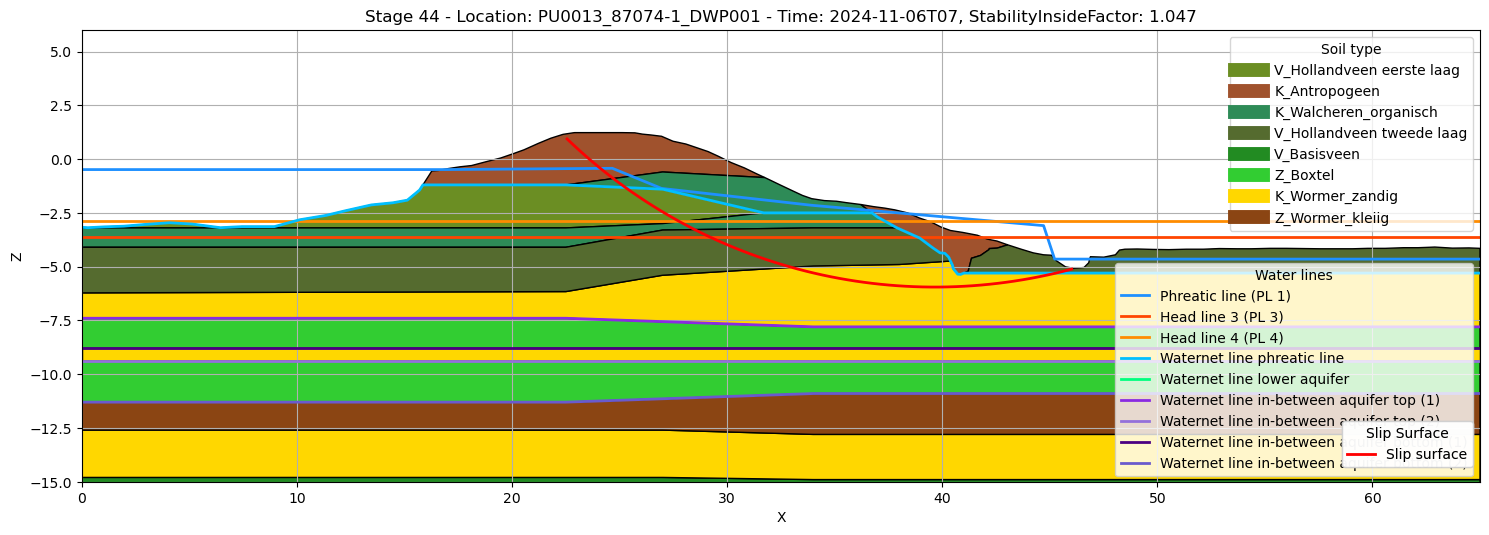

In [21]:
fig, ax = combine_damlive_results.plot_stage(
    stage_id=int(stage_id[0]),
    xlim=(0, 65),
    ylim=(-15, 6),
)
sf = df_corresponding_output.set_index("parameter_code").loc[
    "StabilityInsideFactor", "value"
]
ax.set_title(
    f"Stage {stage_id[0]} - Location: {loc} - Time: {time}, StabilityInsideFactor: {sf:.3f}"
);